In [2]:
import pandas as pd

# Load the CSV files
df1 = pd.read_csv('./TESS13_jtayar_Tlt13.csv')
#df2 = pd.read_csv('TOI_Mar2025_1pt5to4_R_with_extra_columns.csv')
df2 = pd.read_csv('TOI_Mar2025_0to6_R.csv')

# Print the column names for each file
print("Columns in TESS13_jtayar_Tlt13.csv:")
print(df1.columns.tolist())

print("\nColumns in TOI_Mar2025_1pt5to6_R.csv:")
print(df2.columns.tolist())

# Load the TSV file (fix: correct argument is 'skiprows', not 'skiplines')
df_bioverse = pd.read_csv('bioverse.tsv', sep='|', skiprows=57)

# Print the column names for the TSV file
print("\nColumns in bioverse.tsv:")
print(df_bioverse.columns.tolist())


Columns in TESS13_jtayar_Tlt13.csv:
['id', 'TWOMASS', 'tmag']

Columns in TOI_Mar2025_1pt5to6_R.csv:
['toi', 'id', 'tfopwg_disp', 'rastr', 'ra', 'decstr', 'dec', 'st_pmra', 'st_pmraerr1', 'st_pmraerr2', 'st_pmralim', 'st_pmdec', 'st_pmdecerr1', 'st_pmdecerr2', 'st_pmdeclim', 'pl_tranmid', 'pl_tranmiderr1', 'pl_tranmiderr2', 'pl_tranmidlim', 'pl_orbper', 'pl_orbpererr1', 'pl_orbpererr2', 'pl_orbperlim', 'pl_trandurh', 'pl_trandurherr1', 'pl_trandurherr2', 'pl_trandurhlim', 'pl_trandep', 'pl_trandeperr1', 'pl_trandeperr2', 'pl_trandeplim', 'pl_rade', 'pl_radeerr1', 'pl_radeerr2', 'pl_radelim', 'pl_insol', 'pl_insolerr1', 'pl_insolerr2', 'pl_insollim', 'pl_eqt', 'pl_eqterr1', 'pl_eqterr2', 'pl_eqtlim', 'st_tmag', 'st_tmagerr1', 'st_tmagerr2', 'st_tmaglim', 'st_dist', 'st_disterr1', 'st_disterr2', 'st_distlim', 'st_teff', 'st_tefferr1', 'st_tefferr2', 'st_tefflim', 'st_logg', 'st_loggerr1', 'st_loggerr2', 'st_logglim', 'st_rad', 'st_raderr1', 'st_raderr2', 'st_radlim', 'toi_created', 'rowu

/var/folders/m_/l_xwjgkd4dn3xl_27hw7d3sh0000gn/T/ipykernel_92489/2907337652.py:16: DtypeWarning: Columns (3,4,12,13,14,15,16) have mixed types. Specify dtype option on import or set low_memory=False.
  df_bioverse = pd.read_csv('bioverse.tsv', sep='|', skiprows=57)


In [3]:
# Cross-match all three dataframes
# df1: id + TWOMASS, df2: id, df3 (bioverse): 2MASS

# Prepare df1: drop NaNs and standardize
df1_clean = df1.dropna(subset=['id', 'TWOMASS'])
df1_clean['id'] = df1_clean['id'].astype(str).str.strip()
df1_clean['TWOMASS'] = df1_clean['TWOMASS'].astype(str).str.strip()

# Prepare df2: drop NaNs and standardize
df2_clean = df2.dropna(subset=['id'])
df2_clean['id'] = df2_clean['id'].astype(str).str.strip()

# Prepare df3: drop NaNs and standardize
df3_clean = df_bioverse.dropna(subset=['2MASS'])
df3_clean['2MASS'] = df3_clean['2MASS'].astype(str).str.strip()

# Merge df1 and df2 on 'id'
merged_12 = df1_clean.merge(df2_clean, on='id', suffixes=('_df1', '_df2'))

# Merge with df3 using df1's TWOMASS column matched to df3's 2MASS column
merged_all = merged_12.merge(df3_clean, left_on='TWOMASS', right_on='2MASS', suffixes=(None, '_bioverse'))


# Convert Teff to numeric (coerce errors to NaN)
merged_all['Teff'] = pd.to_numeric(merged_all['Teff'], errors='coerce')
merged_all['Rad'] = pd.to_numeric(merged_all['Rad'], errors='coerce')

# Drop rows with NaN in Teff or Rad
merged_all= merged_all.dropna(subset=['Teff', 'Rad'])


print(f"df1 shape: {df1.shape}")
print(f"df2 shape: {df2.shape}")
print(f"df3 (bioverse) shape: {df_bioverse.shape}")
print(f"\nMerged df1+df2 on 'id': {merged_12.shape}")
print(f"Final merged (all three): {merged_all.shape}")
merged_all.head()

/var/folders/m_/l_xwjgkd4dn3xl_27hw7d3sh0000gn/T/ipykernel_92489/2665568930.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1_clean['id'] = df1_clean['id'].astype(str).str.strip()
/var/folders/m_/l_xwjgkd4dn3xl_27hw7d3sh0000gn/T/ipykernel_92489/2665568930.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1_clean['TWOMASS'] = df1_clean['TWOMASS'].astype(str).str.strip()


df1 shape: (13274422, 3)
df2 shape: (1803, 67)
df3 (bioverse) shape: (286393, 27)

Merged df1+df2 on 'id': (1750, 69)
Final merged (all three): (743, 96)


,id,TWOMASS,tmag,toi,tfopwg_disp,rastr,ra,decstr,dec,st_pmra,...,RUWE,GCNS,Gaiabin,AObin,DR3bin,SIMBADbin,Any-bin,SVel,r_SVel,SimbadName
0,337217173,02391735+0728169,11.5546,7049.01,PC,02h39m17.83s,39.824291,+07d28m15.01s,7.470835,480.817,...,1.10,F,F,F,F,F,F,0.5433,1,G 76-19
1,201186294,03453363+3706438,11.0136,1634.01,CP,03h45m33.75s,56.390610,+37d06m44.21s,37.112280,81.643,...,1.23,T,T,F,F,F,T,-17.5923,1,PM J03455+3706
2,396356111,00102406+5829220,7.3307,2056.01,APC,00h10m23.9s,2.599567,+58d29m21.98s,58.489439,-98.605,...,0.98,T,T,F,F,F,T,-22.5557,1,HD 583
3,67881560,00372337+4054198,10.3337,6018.01,PC,00h37m23.31s,9.347123,+40d54m18.6s,40.905168,-50.997,...,0.99,F,F,F,F,F,F,-13.0325,1,TYC 2788-218-1
4,243187830,01073785+2257189,7.3551,2009.01,PC,01h07m37.99s,16.908292,+22d57m10.32s,22.952868,103.070,...,1.21,T,T,F,F,F,T,6.5903,1,HD 6660


In [4]:
# Print the pl_trandep column for all rows
print(merged_all[['id', 'toi', 'pl_trandep']].to_string())

            id      toi    pl_trandep
0    337217173  7049.01   6555.000000
1    201186294  1634.01   1519.669587
2    396356111  2056.01    300.000000
3     67881560  6018.01    571.313890
4    243187830  2009.01    865.169438
5    243185500  1468.01   2937.495321
6    243185500  1468.02   1214.006659
7    422914082  4317.01   1862.694984
8    380887434  4527.01    330.817374
9    249945230  1563.01   4496.000000
10   422756130  1695.01   1183.606071
11   461635621  4460.01   1025.000000
12   396562848  1640.01   2089.244411
13   258804746  2431.01    540.000000
14   408618999  1736.01    446.000000
15   422912527  6980.01    409.341348
16   279922257  6007.01   3029.158585
17   150901009  6653.01   1000.000000
18   384888319  4529.01   1352.762211
19   306263608  1471.01   1415.000000
20   306263608  1471.02   1193.000000
21   318753380  2443.01   1393.381480
22   420051632  2429.01    680.702056
23   257774438  4648.01    407.105054
24   240968774  1467.01   1437.108603
25   2703553

3000-3500: 1000 bootstrap samples, std = 0.0641
3500-4000: 1000 bootstrap samples, std = 0.0476
4000-4500: 1000 bootstrap samples, std = 0.0542
4500-5000: 1000 bootstrap samples, std = 0.0543
5000-5500: 1000 bootstrap samples, std = 0.0546
5500-6000: 1000 bootstrap samples, std = 0.0525
6000-6500: 1000 bootstrap samples, std = 0.0749
6500-7000: 1000 bootstrap samples, std = nan

Mean Radius by Temperature Bin:
Teff_bin
3000-3500    2.419341
3500-4000    2.465855
4000-4500    2.702822
4500-5000    2.636743
5000-5500    2.587587
5500-6000    2.686479
6000-6500    2.568438
6500-7000    3.405696
Name: Rp_recalc_earth_rad, dtype: float64
Planets per bin:
Teff_bin
3000-3500    48
3500-4000    85
4000-4500    68
4500-5000    72
5000-5500    76
5500-6000    84
6000-6500    30
6500-7000     3
Name: count, dtype: int64


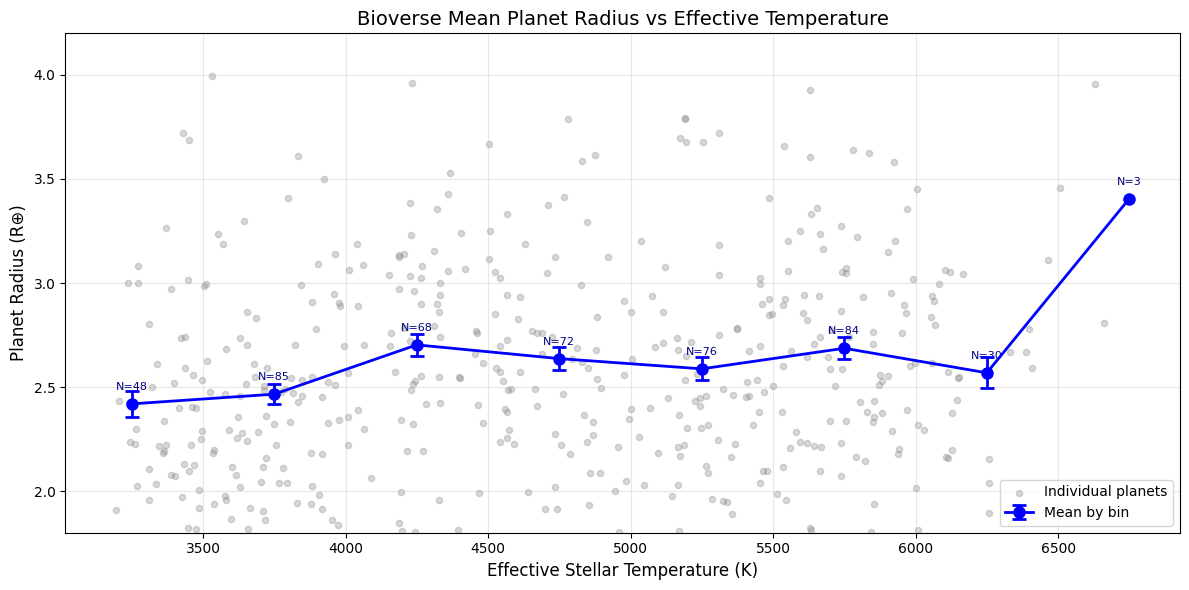

In [5]:
import matplotlib.pyplot as plt
import numpy as np

# Create temperature bins from 3000 to 7000K in 500K intervals
bins = np.arange(3000, 7001, 500)
bin_labels = [f"{bins[i]}-{bins[i+1]}" for i in range(len(bins)-1)]

# Bin the data by stellar effective temperature
merged_all['Teff_bin'] = pd.cut(merged_all['Teff'], bins=bins, labels=bin_labels)

# Calculate mean radius for each temperature bin
transit_depths = merged_all['pl_trandep'] #units of ppm
merged_all['pl_tranfrac'] = transit_depths / 1e6
#print(merged_all['pl_tranfrac'])
#print(merged_all['Rad'])
merged_all['Rp_recalc_solar_rad'] = np.sqrt(merged_all['pl_tranfrac']) * merged_all['Rad']
#print(merged_all['Rp_recalc_solar_rad'])
merged_all['Rp_recalc_earth_rad'] = merged_all['Rp_recalc_solar_rad'] * 109.1
#print(merged_all['Rp_recalc_earth_rad'])


merged_all_cut = merged_all[(merged_all['Rp_recalc_earth_rad'] <= 4) & (merged_all['Rp_recalc_earth_rad'] >= 1.8)]
merged_all_cut = merged_all_cut.dropna(subset=['Teff_bin', 'Rp_recalc_earth_rad'])

# Calculate bin centers for plotting the mean values
bin_centers = [(bins[i] + bins[i+1]) / 2 for i in range(len(bins)-1)]
mean_rad_by_teff = merged_all_cut.groupby('Teff_bin')['Rp_recalc_earth_rad'].mean()

# Bootstrap error bars
n_bootstrap = 1000
bootstrap_means = {bin_label: [] for bin_label in bin_labels}

for _ in range(n_bootstrap):
    # Resample with replacement
    resampled = merged_all_cut.sample(n=len(merged_all_cut), replace=True)
    # Calculate mean for each bin
    bin_means = resampled.groupby('Teff_bin')['Rp_recalc_earth_rad'].mean()
    for bin_label in bin_means.index:
        bootstrap_means[bin_label].append(bin_means[bin_label])

# Calculate standard errors from bootstrap distributions
std_errors_dict = {}
for bin_label in mean_rad_by_teff.index:
    if bin_label in bootstrap_means and len(bootstrap_means[bin_label]) > 0:
        std_errors_dict[bin_label] = np.std(bootstrap_means[bin_label])
        print(f"{bin_label}: {len(bootstrap_means[bin_label])} bootstrap samples, std = {std_errors_dict[bin_label]:.4f}")
    else:
        std_errors_dict[bin_label] = 0
        print(f"{bin_label}: No bootstrap samples!")

# Create aligned arrays for plotting
valid_bin_centers = [bin_centers[i] for i, label in enumerate(bin_labels) if label in mean_rad_by_teff.index]
valid_std_errors = [std_errors_dict[label] for label in mean_rad_by_teff.index]

# Plot with KDE distributions
from scipy.stats import gaussian_kde

fig, (ax_main) = plt.subplots(1, 1, figsize=(12, 6))#, gridspec_kw={'width_ratios': [2, 1]})

# Main scatter plot
ax_main.scatter(merged_all_cut['Teff'], merged_all_cut['Rp_recalc_earth_rad'], alpha=0.3, s=20, c='gray', label='Individual planets')
ax_main.errorbar(valid_bin_centers, mean_rad_by_teff.values, yerr=valid_std_errors, 
                 marker='o', linewidth=2, markersize=8, color='blue', 
                 label='Mean by bin', zorder=5, capsize=5, capthick=2)
ax_main.set_xlabel('Effective Stellar Temperature (K)', fontsize=12)
ax_main.set_ylabel('Planet Radius (R⊕)', fontsize=12)
ax_main.set_title('Bioverse Mean Planet Radius vs Effective Temperature', fontsize=14)
ax_main.legend()
ax_main.grid(True, alpha=0.3)
ax_main.set_ylim(1.8, 4.2)

# # KDE plot for each temperature bin
# colors = plt.cm.RdYlBu_r(np.linspace(0, 1, len(bin_labels)))
# radius_range = np.linspace(1.8, 4.2, 200)

# for i, bin_label in enumerate(bin_labels):
#     bioverse_bin_data = merged_all_cut[merged_all_cut['Teff_bin'] == bin_label]['Rp_recalc_earth_rad']
    
#     if len(bioverse_bin_data) > 3:  # Need at least a few points for KDE
#         kde = gaussian_kde(bioverse_bin_data)
#         density = kde(radius_range)
#         ax_kde.plot(density, radius_range, label=f'{bin_label} K', color=colors[i], linewidth=2, alpha=0.8)
        
#         # Calculate and plot mean as dotted line
#         mean_radius = bioverse_bin_data.mean()
#         ax_kde.axhline(mean_radius, color=colors[i], linestyle=':', linewidth=2, alpha=0.7)
        
#         # Add point at the peak
#         peak_idx = np.argmax(density)
#         peak_density = density[peak_idx]
#         peak_radius = radius_range[peak_idx]
#         ax_kde.scatter(peak_density, peak_radius, color=colors[i], s=80, zorder=10)

# ax_kde.set_ylim(1.8, 4.2)
# ax_kde.set_xlabel('Density', fontsize=12)
# ax_kde.set_ylabel('Planet Radius (R⊕)', fontsize=12)
# ax_kde.set_title('Distribution by Temperature Bin', fontsize=14)
# ax_kde.legend(fontsize=9, loc='best')
# ax_kde.grid(True, alpha=0.3)

# plt.tight_layout()
# plt.show()

# Print statistics
print("\nMean Radius by Temperature Bin:")
print(mean_rad_by_teff)
print(f'Planets per bin:')
print(merged_all_cut['Teff_bin'].value_counts().sort_index())
# Add per-bin sample size labels and save figure as PNG
for x, bin_label in zip(valid_bin_centers, mean_rad_by_teff.index):
    n_in_bin = int((merged_all_cut["Teff_bin"] == bin_label).sum())
    y = mean_rad_by_teff.loc[bin_label]
    if np.isfinite(y):
        ax_main.annotate(
            f"N={n_in_bin}",
            (x, y),
            xytext=(0, 10),
            textcoords="offset points",
            ha="center",
            fontsize=8,
            color="navy",
        )

plt.tight_layout()
plt.savefig("bioverse_mean_radius_vs_teff.png", dpi=300, bbox_inches="tight")
plt.show()

3000-3500: 1000 bootstrap samples, std = 0.0741
3500-4000: 1000 bootstrap samples, std = 0.0607
4000-4500: 1000 bootstrap samples, std = 0.0821
4500-5000: 1000 bootstrap samples, std = 0.0647
5000-5500: 1000 bootstrap samples, std = 0.0566
5500-6000: 1000 bootstrap samples, std = 0.0723
6000-6500: 1000 bootstrap samples, std = 0.0987
6500-7000: 1000 bootstrap samples, std = nan


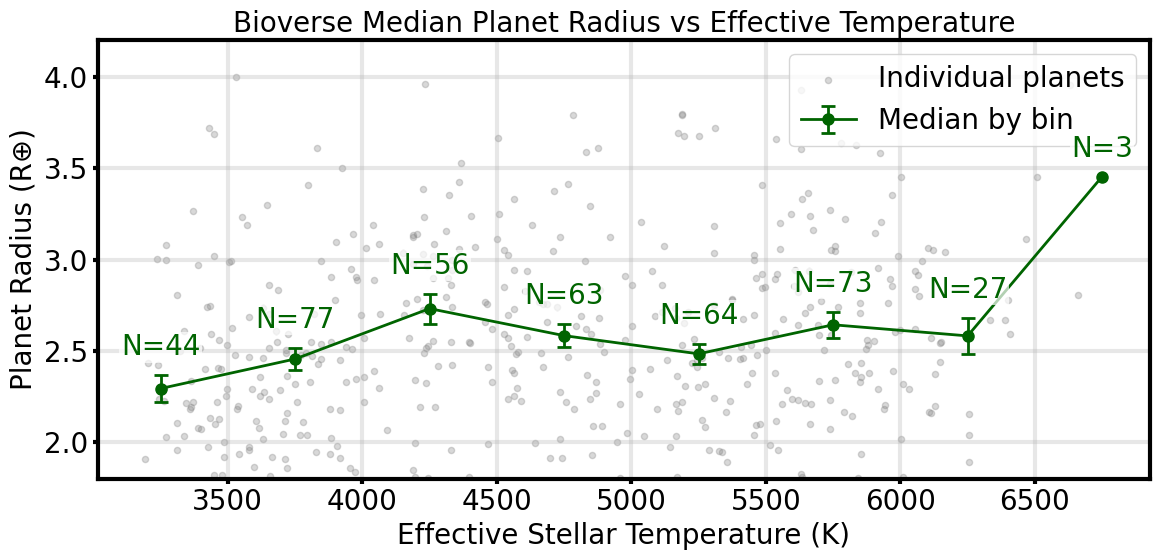


Median Radius by Temperature Bin:
Teff_bin
3000-3500    2.293676
3500-4000    2.455502
4000-4500    2.731325
4500-5000    2.583377
5000-5500    2.483657
5500-6000    2.642770
6000-6500    2.581958
6500-7000    3.454312
Name: Rp_recalc_earth_rad, dtype: float64

Stars per bin (unique id):
Teff_bin
3000-3500    44
3500-4000    77
4000-4500    56
4500-5000    63
5000-5500    64
5500-6000    73
6000-6500    27
6500-7000     3
Name: id, dtype: int64

Planets per bin:
Teff_bin
3000-3500    48
3500-4000    85
4000-4500    68
4500-5000    72
5000-5500    76
5500-6000    84
6000-6500    30
6500-7000     3
Name: count, dtype: int64
Saved: bioverse_median_radius_vs_teff.png


In [12]:

plt.rcParams.update({'lines.linewidth': 3, 'axes.linewidth': 3, 'grid.linewidth': 3, 'xtick.major.width': 3, 'ytick.major.width': 3, 'xtick.minor.width': 3, 'ytick.minor.width': 3})
plt.rcParams.update({'font.size': 20})
# Calculate median radius for each temperature bin
median_rad_by_teff = merged_all_cut.groupby('Teff_bin')['Rp_recalc_earth_rad'].median()

# Count unique stars per bin (N stars)
stars_per_bin = merged_all_cut.groupby('Teff_bin')['id'].nunique()

# Bootstrap error bars for median
n_bootstrap = 1000
bootstrap_medians = {bin_label: [] for bin_label in bin_labels}

for _ in range(n_bootstrap):
    resampled = merged_all_cut.sample(n=len(merged_all_cut), replace=True)
    bin_medians = resampled.groupby('Teff_bin')['Rp_recalc_earth_rad'].median()
    for bin_label in bin_medians.index:
        bootstrap_medians[bin_label].append(bin_medians[bin_label])

# Calculate standard errors from bootstrap distributions
std_errors_median_dict = {}
for bin_label in median_rad_by_teff.index:
    if bin_label in bootstrap_medians and len(bootstrap_medians[bin_label]) > 0:
        std_errors_median_dict[bin_label] = np.std(bootstrap_medians[bin_label])
        print(f"{bin_label}: {len(bootstrap_medians[bin_label])} bootstrap samples, std = {std_errors_median_dict[bin_label]:.4f}")
    else:
        std_errors_median_dict[bin_label] = 0
        print(f"{bin_label}: No bootstrap samples!")

# Create aligned arrays for plotting
valid_bin_centers_median = [bin_centers[i] for i, label in enumerate(bin_labels) if label in median_rad_by_teff.index]
valid_std_errors_median = [std_errors_median_dict[label] for label in median_rad_by_teff.index]

fig, ax_main = plt.subplots(1, 1, figsize=(12, 6))

# Main scatter plot
ax_main.scatter(
    merged_all_cut['Teff'],
    merged_all_cut['Rp_recalc_earth_rad'],
    alpha=0.3,
    s=20,
    c='gray',
    label='Individual planets'
)
ax_main.errorbar(
    valid_bin_centers_median,
    median_rad_by_teff.values,
    yerr=valid_std_errors_median,
    marker='o',
    linewidth=2,
    markersize=8,
    color='darkgreen',
    label='Median by bin',
    zorder=5,
    capsize=5,
    capthick=2
)

# Add N=number of stars in each bin (offset above error bars)
for x, bin_label in zip(valid_bin_centers_median, median_rad_by_teff.index):
    y = median_rad_by_teff.loc[bin_label]
    n_stars = int(stars_per_bin.get(bin_label, 0))
    yerr = std_errors_median_dict.get(bin_label, 0.0)

    if np.isfinite(y):
        if not np.isfinite(yerr):
            yerr = 0.0

        ax_main.annotate(
            f"N={n_stars}",
            (x, y + yerr),              # place above top of error bar
            xytext=(0, 10),             # extra upward offset in points
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=20,
            color="darkgreen",
            zorder=10,
            clip_on=False,
            bbox=dict(facecolor="white", edgecolor="none", alpha=0.7, pad=1.0),
        )


ax_main.set_xlabel('Effective Stellar Temperature (K)', fontsize=20)
ax_main.set_ylabel('Planet Radius (R⊕)', fontsize=20)
ax_main.set_title('Bioverse Median Planet Radius vs Effective Temperature', fontsize=20)
ax_main.legend()
ax_main.grid(True, alpha=0.3)
ax_main.set_ylim(1.8, 4.2)

plt.tight_layout()
plt.show()

# Print statistics
print("\nMedian Radius by Temperature Bin:")
print(median_rad_by_teff)
print("\nStars per bin (unique id):")
print(stars_per_bin.sort_index())
print("\nPlanets per bin:")
print(merged_all_cut['Teff_bin'].value_counts().sort_index())

fig.savefig("bioverse_median_radius_vs_teff.png", dpi=300, bbox_inches="tight")
print("Saved: bioverse_median_radius_vs_teff.png")

/var/folders/m_/l_xwjgkd4dn3xl_27hw7d3sh0000gn/T/ipykernel_92489/2385954861.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_toi_cut['Teff_bin'] = pd.cut(df_toi_cut['Teff'], bins=bins, labels=bin_labels)


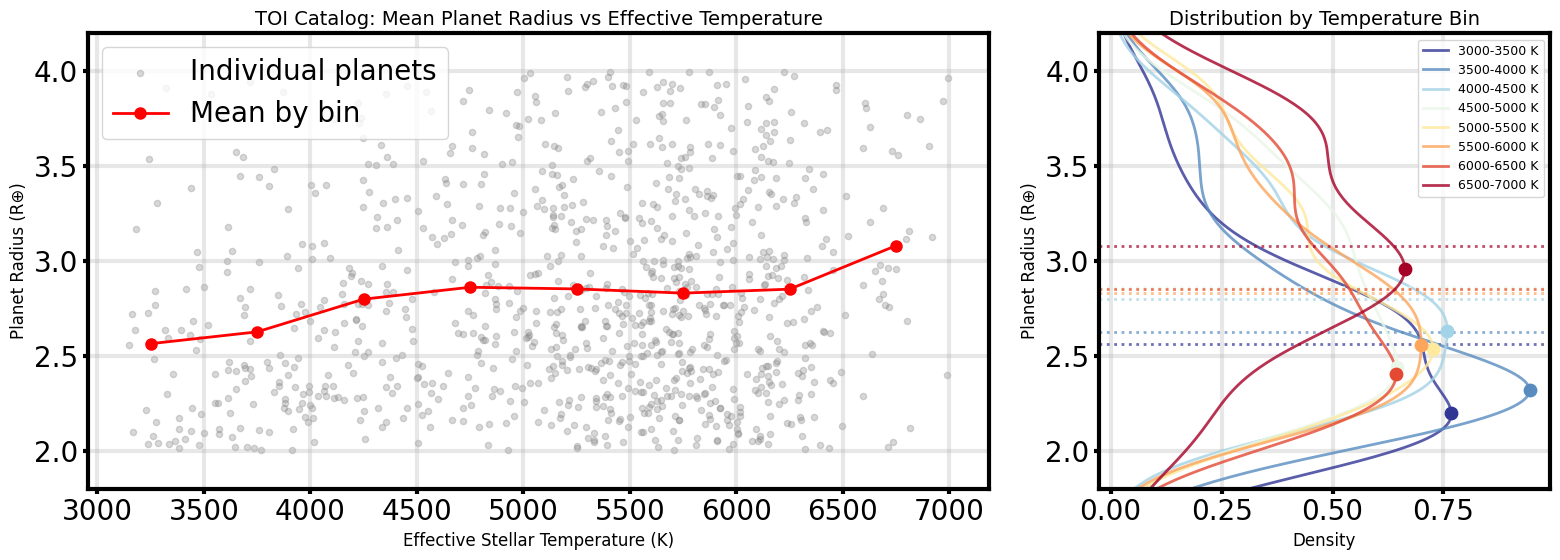


Mean Radius by Temperature Bin:
Teff_bin
3000-3500    2.564461
3500-4000    2.626650
4000-4500    2.799049
4500-5000    2.861787
5000-5500    2.853005
5500-6000    2.830856
6000-6500    2.851709
6500-7000    3.081037
Name: pl_rade, dtype: float64

Total planets plotted: 1012
Planets per bin:
Teff_bin
3000-3500     43
3500-4000     84
4000-4500    100
4500-5000    118
5000-5500    202
5500-6000    263
6000-6500    166
6500-7000     36
Name: count, dtype: int64


In [7]:
# Load the CSV file
df_toi = pd.read_csv('TOI_Mar2025_1pt5to4_R_with_extra_columns.csv')

# Convert Teff and pl_rade to numeric (coerce errors to NaN)
df_toi['Teff'] = pd.to_numeric(df_toi['st_teff'], errors='coerce')
df_toi['pl_rade'] = pd.to_numeric(df_toi['pl_rade'], errors='coerce')

# Drop rows with NaN in Teff or pl_rade
df_toi_clean = df_toi.dropna(subset=['Teff', 'pl_rade'])

# Filter for radius range 1.5-4.0 R⊕
df_toi_cut = df_toi_clean[(df_toi_clean['pl_rade'] >= 2) & (df_toi_clean['pl_rade'] <= 4.0)]

# Create temperature bins from 3000 to 7000K in 500K intervals
df_toi_cut['Teff_bin'] = pd.cut(df_toi_cut['Teff'], bins=bins, labels=bin_labels)

# Calculate mean radius for each temperature bin
mean_rad_toi = df_toi_cut.groupby('Teff_bin')['pl_rade'].mean()

# Plot with KDE distributions
fig, (ax_main, ax_kde) = plt.subplots(1, 2, figsize=(16, 6), gridspec_kw={'width_ratios': [2, 1]})

# Main scatter plot
ax_main.scatter(df_toi_cut['Teff'], df_toi_cut['pl_rade'], alpha=0.3, s=20, c='gray', label='Individual planets')
ax_main.plot(bin_centers, mean_rad_toi.values, marker='o', linewidth=2, markersize=8, color='red', label='Mean by bin', zorder=5)
ax_main.set_xlabel('Effective Stellar Temperature (K)', fontsize=12)
ax_main.set_ylabel('Planet Radius (R⊕)', fontsize=12)
ax_main.set_title('TOI Catalog: Mean Planet Radius vs Effective Temperature', fontsize=14)
ax_main.legend()
ax_main.grid(True, alpha=0.3)
ax_main.set_ylim(1.8, 4.2)

# KDE plot for each temperature bin
colors = plt.cm.RdYlBu_r(np.linspace(0, 1, len(bin_labels)))
radius_range = np.linspace(1.8, 4.2, 200)

for i, bin_label in enumerate(bin_labels):
    toi_bin_data = df_toi_cut[df_toi_cut['Teff_bin'] == bin_label]['pl_rade']
    
    if len(toi_bin_data) > 3:  # Need at least a few points for KDE
        kde = gaussian_kde(toi_bin_data)
        density = kde(radius_range)
        ax_kde.plot(density, radius_range, label=f'{bin_label} K', color=colors[i], linewidth=2, alpha=0.8)
        
        # Calculate and plot mean as dotted line
        mean_radius = toi_bin_data.mean()
        ax_kde.axhline(mean_radius, color=colors[i], linestyle=':', linewidth=2, alpha=0.7)
        
        # Add point at the peak
        peak_idx = np.argmax(density)
        peak_density = density[peak_idx]
        peak_radius = radius_range[peak_idx]
        ax_kde.scatter(peak_density, peak_radius, color=colors[i], s=80, zorder=10)

ax_kde.set_ylim(1.8, 4.2)
ax_kde.set_xlabel('Density', fontsize=12)
ax_kde.set_ylabel('Planet Radius (R⊕)', fontsize=12)
ax_kde.set_title('Distribution by Temperature Bin', fontsize=14)
ax_kde.legend(fontsize=9, loc='best')
ax_kde.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print statistics
print("\nMean Radius by Temperature Bin:")
print(mean_rad_toi)
print(f"\nTotal planets plotted: {len(df_toi_cut)}")
print(f'Planets per bin:')
print(df_toi_cut['Teff_bin'].value_counts().sort_index())

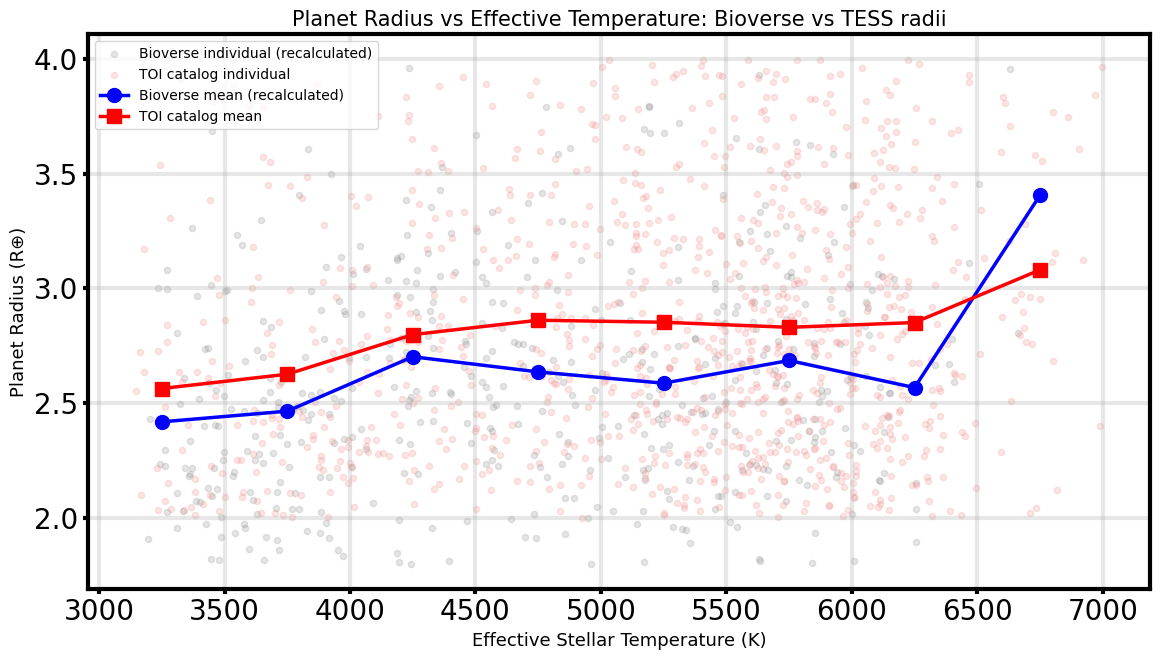


Bioverse Recalculation Planets per bin:
Teff_bin
3000-3500    48
3500-4000    85
4000-4500    68
4500-5000    72
5000-5500    76
5500-6000    84
6000-6500    30
6500-7000     3
Name: count, dtype: int64

OG Planets per bin:
Teff_bin
3000-3500     43
3500-4000     84
4000-4500    100
4500-5000    118
5000-5500    202
5500-6000    263
6000-6500    166
6500-7000     36
Name: count, dtype: int64


In [8]:
# Combined plot: Bioverse recalculated vs TOI catalog
plt.figure(figsize=(12, 7))

# Plot Bioverse individual points (recalculated)
plt.scatter(merged_all_cut['Teff'], merged_all_cut['Rp_recalc_earth_rad'], 
            alpha=0.2, s=20, c='gray', label='Bioverse individual (recalculated)')

# Plot TOI catalog individual points
plt.scatter(df_toi_cut['Teff'], df_toi_cut['pl_rade'], 
            alpha=0.2, s=20, c='lightcoral', label='TOI catalog individual')

# Plot Bioverse mean values
plt.plot(bin_centers, mean_rad_by_teff.values, marker='o', linewidth=2.5, markersize=10, 
         color='blue', label='Bioverse mean (recalculated)', zorder=5)

# Plot TOI catalog mean values
plt.plot(bin_centers, mean_rad_toi.values, marker='s', linewidth=2.5, markersize=10, 
         color='red', label='TOI catalog mean', zorder=5)

plt.xlabel('Effective Stellar Temperature (K)', fontsize=13)
plt.ylabel('Planet Radius (R⊕)', fontsize=13)
plt.title('Planet Radius vs Effective Temperature: Bioverse vs TESS radii', fontsize=15,)
plt.legend(fontsize=10, loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print combined statistics

# print("\nMean Radius by Temperature Bin:")
# print(mean_rad_by_teff)
print(f'\nBioverse Recalculation Planets per bin:')
print(merged_all_cut['Teff_bin'].value_counts().sort_index())


# print("\nMean Radius by Temperature Bin:")
# print(mean_rad_toi)
print(f'\nOG Planets per bin:')
print(df_toi_cut['Teff_bin'].value_counts().sort_index())